# Hydroelectric Flow Rate Prediction
Predicting river discharge (ft³/s) from gage height and lagged flow using linear regression.

**Station:** USGS-12510500 (Yakima River, WA)  
**Why flow rate?** Power output is directly proportional to flow rate (P = ρgHQη), so predicting flow is equivalent to predicting power — without needing to assume unknown plant parameters like head height.

## 1. Imports

In [2]:
import pandas as pd
import urllib.request
import json
from sklearn.linear_model import LinearRegression
from dateutil import parser
from datetime import datetime

## 2. Fetch Data from USGS

In [3]:
url = (f"https://waterservices.usgs.gov/nwis/iv/?sites=13334300&parameterCd=00060&startDT=2024-01-01&endDT=2026-01-01&format=json")
response = urllib.request.urlopen(url).read().decode('utf-8')

In [11]:
data = json.loads(response)
flow_data = data['value']['timeSeries'][0]['values'][0]['value']

lists = []
for data_point in flow_data:
    time = parser.parse(data_point['dateTime'])
    row = [time, float(data_point['value'])]
    lists.append(row)

## 3. Clean & Prepare

In [14]:
df = pd.DataFrame(lists, columns=['datetime', 'flow'])
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.set_index('datetime').sort_index()
df = df.resample('1D').mean()
df.head()

,flow
datetime,
2024-01-01 00:00:00+00:00,17137.500000
2024-01-02 00:00:00+00:00,16809.375000
2024-01-03 00:00:00+00:00,18343.750000
2024-01-04 00:00:00+00:00,18384.375000
2024-01-05 00:00:00+00:00,18620.833333


## 4. Feature Engineering
We predict next-hour flow rate using current and past gage height and flow as inputs.

In [27]:
for i in range(1, 15):
    df[f'day_{i}'] = df['flow'].shift(i)

df['target'] = df['flow'].shift(-1)
days = [
    'day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6', 'day_7', 
    'day_8', 'day_9', 'day_10', 'day_11', 'day_12', 'day_13', 'day_14'
]

X = df[days].values
y = df['target'].values
df.head()

C:\Users\akama\AppData\Local\Temp\ipykernel_15404\3743867291.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'day_{i}'] = df['flow'].shift(i)
C:\Users\akama\AppData\Local\Temp\ipykernel_15404\3743867291.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['target'] = df['flow'].shift(-1)


,flow,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,day_10,day_11,day_12,day_13,day_14,target
datetime,,,,,,,,,,,,,,,,
2024-02-26 00:00:00+00:00,23478.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29980.208333
2024-02-27 00:00:00+00:00,29980.208333,23478.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30201.041667
2024-02-28 00:00:00+00:00,30201.041667,29980.208333,23478.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30066.666667
2024-02-29 00:00:00+00:00,30066.666667,30201.041667,29980.208333,23478.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31386.458333
2024-03-01 00:00:00+00:00,31386.458333,30066.666667,30201.041667,29980.208333,23478.125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30481.250000


## 5. Train / Test Split

In [16]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = df.index[split:]

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 6. Visualize Results

<Axes: title={'center': 'Flow Rate: Predicted vs Actual'}, xlabel='datetime', ylabel='Discharge (ft³/s)'>

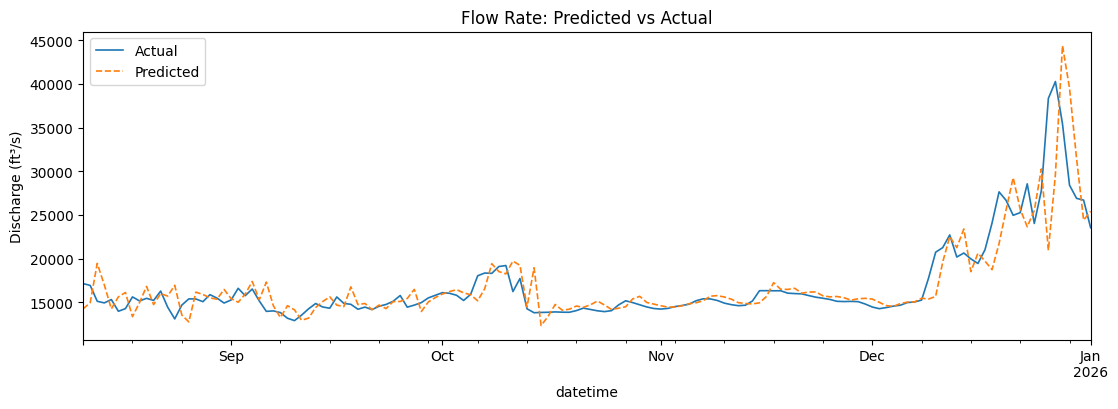

In [17]:
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
}, index=dates_test)

results_df.plot(
    figsize=(13, 4), 
    style=['-', '--'],
    linewidth=1.2,
    title='Flow Rate: Predicted vs Actual',
    ylabel='Discharge (ft³/s)'
)

In [18]:
url = "https://waterservices.usgs.gov/nwis/dv/?stateCd=WA&parameterCd=00060&statCd=00003&startDT=2024-01-01&endDT=2024-12-31&siteType=ST&siteStatus=all&format=json"
data = json.loads(urllib.request.urlopen(url).read().decode('utf-8'))

In [19]:
rows = []
for series in data['value']['timeSeries']:
    site = series['sourceInfo']
    values = [float(pt['value']) for pt in series['values'][0]['value'] if float(pt['value']) >= 0]
    if values:
        rows.append([site['siteName'], site['siteCode'][0]['value'], sum(values)])

sites_df = pd.DataFrame(rows, columns=['site_name', 'site_id', 'total_flow_cfs'])
sites_df = sites_df.sort_values('total_flow_cfs', ascending=False).reset_index(drop=True)
best = sites_df.iloc[0]
print(f"Best candidate: {best['site_name']} — {best['total_flow_cfs']:,.0f} ft³/s cumulative")
sites_df.head(10)

Best candidate: COLUMBIA RIVER AT VANCOUVER, WA — 53,474,600 ft³/s cumulative


,site_name,site_id,total_flow_cfs
0,"COLUMBIA RIVER AT VANCOUVER, WA",14144700,53474600.0
1,"COLUMBIA RIVER BELOW PRIEST RAPIDS DAM, WA",12472800,32274900.0
2,"COLUMBIA RIVER BELOW ROCK ISLAND DAM, WA",12462600,31241600.0
3,"COLUMBIA RIVER BELOW WELLS DAM, WA",12450700,30637400.0
4,"COLUMBIA RIVER AT ROCKY REACH DAM, WA",12453700,30383200.0
5,"COLUMBIA RIVER AT BRIDGEPORT, WA",12438000,28952900.0
6,"COLUMBIA RIVER AT GRAND COULEE, WA",12436500,28873000.0
7,COLUMBIA RIVER AT INTERNATIONAL BOUNDARY,12399500,28574400.0
8,"SNAKE RIVER NEAR ANATONE, WA",13334300,10016400.0
9,"PEND OREILLE RIVER BELOW BOX CANYON NEAR IONE, WA",12396500,6909760.0


NameError: name 'plt' is not defined

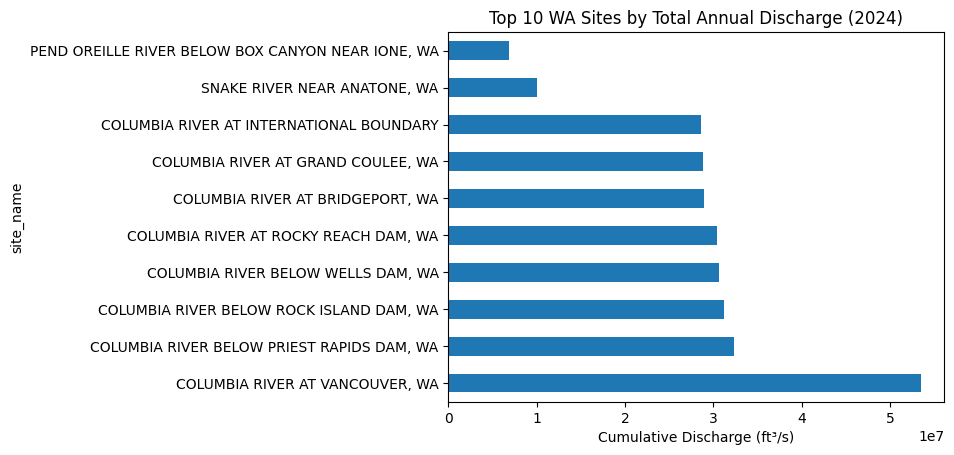

In [10]:
sites_df.head(10).plot.barh(
    x='site_name', y='total_flow_cfs',
    title='Top 10 WA Sites by Total Annual Discharge (2024)',
    xlabel='Cumulative Discharge (ft³/s)', legend=False
)
plt.show()